<a href="https://colab.research.google.com/github/hursoo/big_k-modern_1/blob/main/gb_121_so_inner_cluster(big1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.개요 및 기본 설정
- 사회주의 필자 내부의 차이

In [1]:
# =================================================================
# 셀 1: 라이브러리 설치
# =================================================================
# 설치 과정 표시, 에러 출력은 숨김

!pip install -q tomotopy==0.13.0 numpy==1.23.5 kneed 2> /dev/null # 2> /dev/null : 에러 출력 메시지를 숨깁니다.

# =================================================================
# 셀 1-1: 나눔 폰트 설치
# =================================================================
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 12.8 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,633 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at

=> "런타임 / 세션 다시 시작"

In [1]:
# =================================================================
# 셀 2: 기본 설정 및 라이브러리 임포트
# =================================================================
# "세션 다시 시작" 후에 이 셀부터 실행합니다.

# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')
print("\n✅ 구글 드라이브 마운트 완료!")

# 경로 지정
file_path = '/content/drive/MyDrive/big_km_history01/'

Mounted at /content/drive

✅ 구글 드라이브 마운트 완료!


In [35]:
import sys
import os, re
import pandas as pd
import numpy as np
print(np.__version__)
import random
import warnings

from tomotopy import DMRModel
from tomotopy import TermWeight
from tomotopy import utils
import tomotopy as tp

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumBarunGothic' # 나눔바른고딕으로 설정 (Colab 기본 포함) ###
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호가 정상 표시되도록 설정

1.23.5


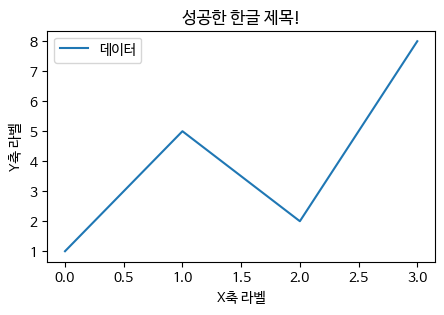

In [36]:
# 그래프 한글 표시 테스트
plt.figure(figsize=(5, 3))
plt.title('성공한 한글 제목!')
plt.xlabel('X축 라벨')
plt.ylabel('Y축 라벨')
plt.plot([1, 5, 2, 8], label='데이터')
plt.legend()
plt.show()

# 2.데이터 불러오기

In [37]:
# 2기 1,2그룹 필자의 문서별 토픽 분포 불러오기

dist_writer_12 = pd.read_excel(file_path + 'result/dist_writer_12.xlsx', index_col=0)
dist_writer_12

,T0,T1,T2,T3,w_new,wn_cls
doc_id,,,,,,
2858,0.192781,0.298942,0.092741,0.415536,이돈화,1
2859,0.001885,0.229673,0.003657,0.764784,이돈화,1
2860,0.413645,0.098331,0.474611,0.013413,이돈화,1
2861,0.427109,0.141999,0.130751,0.300141,이돈화,1
2862,0.259120,0.531298,0.059220,0.150363,이돈화,1
...,...,...,...,...,...,...
6798,0.179044,0.003750,0.772944,0.044262,김철산,2
6799,0.530579,0.005226,0.458731,0.005463,김철산,2
6800,0.800339,0.004267,0.190934,0.004460,김철산,2


In [38]:
# 사회주의 그룹의 문서별 토픽 분포만 추출
dist_writer_2 = dist_writer_12.query('wn_cls == 2').copy()
dist_writer_2

,T0,T1,T2,T3,w_new,wn_cls
doc_id,,,,,,
3646,0.511432,0.068957,0.021907,0.397704,이성태,2
3647,0.290479,0.024773,0.195423,0.489325,이성태,2
3648,0.392492,0.231811,0.002896,0.372800,이성태,2
3649,0.553987,0.125623,0.055733,0.264658,이성태,2
3650,0.388174,0.135066,0.004562,0.472198,이성태,2
...,...,...,...,...,...,...
6798,0.179044,0.003750,0.772944,0.044262,김철산,2
6799,0.530579,0.005226,0.458731,0.005463,김철산,2
6800,0.800339,0.004267,0.190934,0.004460,김철산,2


# 3.군집화
- k-means 군집


--- 2. 최적의 군집 수(K)를 자동으로 탐색합니다. ---
✅ KneeLocator가 찾은 최적의 군집 수는 k=4입니다.


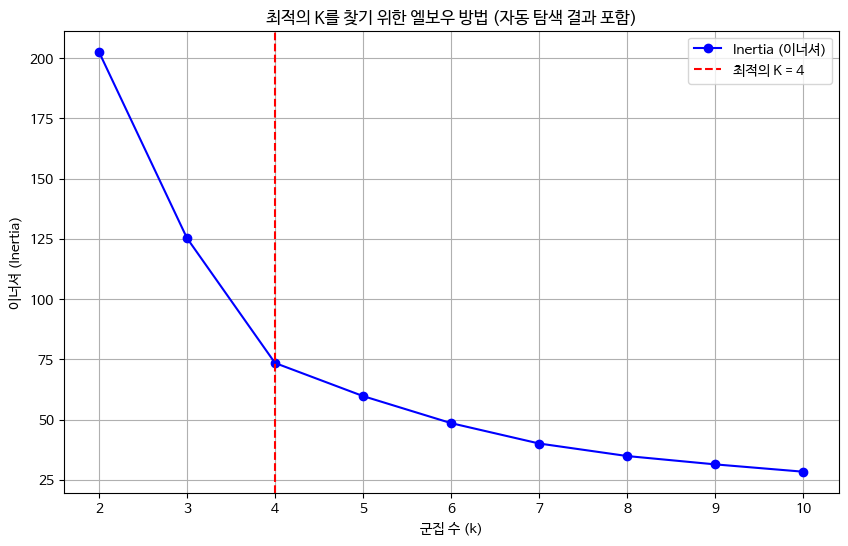

✅ 최적 K값이 표시된 최종 그래프 'optimal_k_elbow_method_final.png' 파일이 저장되었고,
✅ 그래프가 Colab 결과 창에 표시되었습니다.


In [39]:
# =================================================================
# 1. 최적 군집 수(K) 탐색 (Elbow Method & KneeLocator)
# =================================================================
# 이 코드를 실행하기 전에 kneed 라이브러리를 설치해야 합니다.
# !pip install kneed

features = dist_writer_2[['T0', 'T1', 'T2', 'T3']]

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator
import seaborn as sns

print("\n--- 2. 최적의 군집 수(K)를 자동으로 탐색합니다. ---")
inertia = []
K_range = range(2, 11)

# 이전과 동일하게 K별 이너셔 값을 계산합니다.
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features) # 'features'는 토픽 분포 데이터프레임입니다.
    inertia.append(kmeans.inertia_)

# KneeLocator를 사용해 엘보우 지점을 자동으로 찾습니다.
kneedle = KneeLocator(
    K_range,
    inertia,
    S=1.0, # 민감도. 필요시 조정
    curve='convex', # 곡선 유형
    direction='decreasing' # 감소하는 곡선
)

# KneeLocator가 찾은 최적의 K값
optimal_k = kneedle.elbow

# 최적 K값 출력
if optimal_k:
    print(f"✅ KneeLocator가 찾은 최적의 군집 수는 k={optimal_k}입니다.")
else:
    print("⚠️ 엘보우 지점을 자동으로 찾지 못했습니다. k=4를 기본값으로 사용합니다.")
    optimal_k = 4 # 찾지 못할 경우의 기본값

plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'NanumBarunGothic'

# 전체 꺾은선 그래프 그리기
plt.plot(K_range, inertia, 'bo-', label='Inertia (이너셔)')

# KneeLocator가 찾은 엘보우 지점에 수직선 그리기
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'최적의 K = {optimal_k}')

plt.xlabel('군집 수 (k)')
plt.ylabel('이너셔 (Inertia)')
plt.title('최적의 K를 찾기 위한 엘보우 방법 (자동 탐색 결과 포함)')
plt.legend()
plt.grid(True)

# 그래프를 이미지 파일로 저장
plt.savefig('optimal_k_elbow_method_final.png')

# --- [수정 지점] ---
# 그래프를 Colab 노트북 결과 창에 바로 표시
plt.show()

# plt.close() # 이 줄을 주석 처리하거나 삭제합니다.

print("✅ 최적 K값이 표시된 최종 그래프 'optimal_k_elbow_method_final.png' 파일이 저장되었고,")
print("✅ 그래프가 Colab 결과 창에 표시되었습니다.")

In [40]:
# =================================================================
# 2. K-평균 군집화 실행 및 PCA 차원 축소
# =================================================================
print(f"\n--- 2. k={optimal_k}로 K-평균 군집화를 실행하고 PCA로 차원을 축소합니다. ---")

# K-평균 군집화
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
dist_writer_2['cluster'] = kmeans.fit_predict(features)

# PCA를 위한 데이터 스케일링
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# PCA 실행
pca = PCA(n_components=2)
principal_components = pca.fit_transform(features_scaled)
dist_writer_2['pca1'] = principal_components[:, 0]
dist_writer_2['pca2'] = principal_components[:, 1]

print("✅ 군집화 및 PCA 변환을 완료했습니다.")


--- 2. k=4로 K-평균 군집화를 실행하고 PCA로 차원을 축소합니다. ---
✅ 군집화 및 PCA 변환을 완료했습니다.



--- 3. 최종 군집화 결과를 산점도로 시각화하고 저장합니다. ---


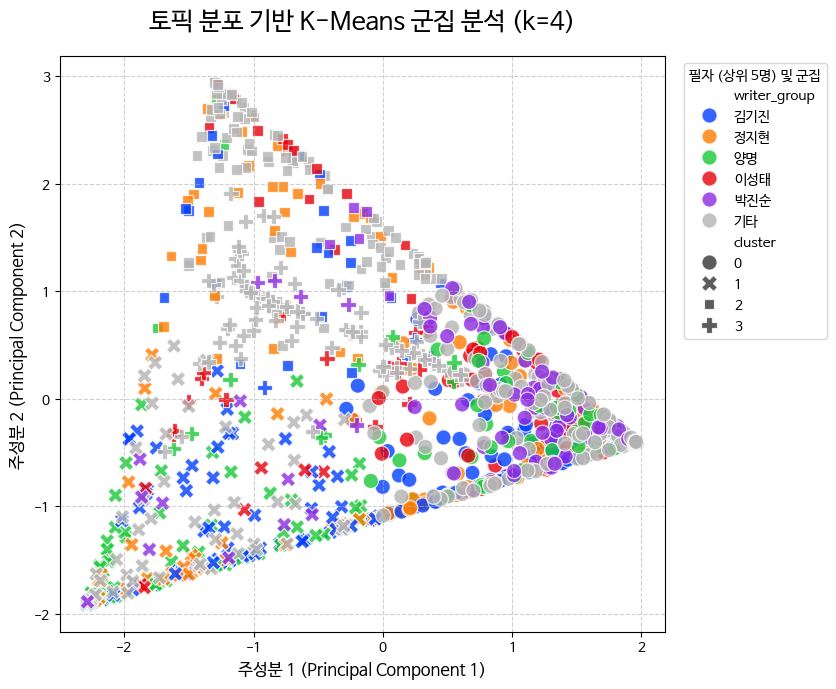

✅ 최종 시각화 결과물 'kmeans_clustering_scatterplot.png' 파일이 저장되었고,
✅ 그래프가 Colab 결과 창에 표시되었습니다.


In [41]:
# =================================================================
# 3. 최종 결과 시각화 (파일 저장 및 Colab 출력)
# =================================================================
print("\n--- 3. 최종 군집화 결과를 산점도로 시각화하고 저장합니다. ---")

# 문서 수 기준 상위 5명 필자 선정
# 'dist_writer_2'는 사전에 정의된 데이터프레임이라고 가정합니다.
top5_writers = dist_writer_2['w_new'].value_counts().nlargest(5).index.tolist()

# 상위 5명 외 필자는 '기타'로 그룹화
# .loc를 사용하여 SettingWithCopyWarning 방지
dist_writer_2.loc[:, 'writer_group'] = dist_writer_2['w_new'].apply(lambda x: x if x in top5_writers else '기타')


# 시각화
plt.figure(figsize=(10, 7))
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# 색상 팔레트 및 순서 설정 (상위 5명 + 기타)
palette_colors = sns.color_palette("bright", n_colors=len(top5_writers))
palette_colors.append((0.7, 0.7, 0.7)) # '기타' 그룹은 회색으로 지정
hue_order = top5_writers + ['기타']

# 산점도 그리기
sns.scatterplot(
    x='pca1',
    y='pca2',
    hue='writer_group',  # 점의 색상은 필자 그룹
    style='cluster',     # 점의 모양은 군집
    data=dist_writer_2,
    s=120,               # 점 크기
    alpha=0.8,
    palette=palette_colors,
    hue_order=hue_order
)

plt.title(f'토픽 분포 기반 K-Means 군집 분석 (k={optimal_k})', fontsize=18, pad=20)
plt.xlabel('주성분 1 (Principal Component 1)', fontsize=12)
plt.ylabel('주성분 2 (Principal Component 2)', fontsize=12)
plt.legend(title='필자 (상위 5명) 및 군집', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(rect=[0, 0, 0.85, 1]) # 범례가 잘리지 않도록 레이아웃 조정

# 최종 그래프 저장
plt.savefig(file_path + 'kmeans_clustering_scatterplot.png')


# --- [수정된 부분] ---
# 그래프를 Colab 노트북 결과 창에 바로 표시합니다.
plt.show()

# plt.close() # 이 라인을 삭제하거나 주석 처리합니다.


print("✅ 최종 시각화 결과물 'kmeans_clustering_scatterplot.png' 파일이 저장되었고,")
print("✅ 그래프가 Colab 결과 창에 표시되었습니다.")

In [42]:
# =================================================================
# 4. 필자-군집 매트릭스 생성 ('기타' 제외)
# =================================================================
print("\n--- 4. '기타'를 제외한 상위 5명 필자의 군집 분포 매트릭스를 생성합니다. ---")

# 'writer_group'이 '기타'가 아닌 행들만 선택하여 새로운 데이터프레임 생성
top5_df = dist_writer_2[dist_writer_2['writer_group'] != '기타'].copy()

# 필터링된 데이터프레임을 사용하여 교차표 생성
writer_cluster_matrix_top5 = pd.crosstab(
    index=top5_df['writer_group'],
    columns=top5_df['cluster']
)

# 생성된 매트릭스 출력
print("✅ ['기타' 제외된 필자-군집 분포 매트릭스]")
print(writer_cluster_matrix_top5)


--- 4. '기타'를 제외한 상위 5명 필자의 군집 분포 매트릭스를 생성합니다. ---
✅ ['기타' 제외된 필자-군집 분포 매트릭스]
cluster        0   1   2   3
writer_group                
김기진           94  72  22   3
박진순           62  11   5   6
양명            46  75   3   9
이성태           56   7  14  17
정지현           75  36  37   0



--- 5. 필자(행) 기준으로 정규화된 매트릭스를 생성합니다. ---
✅ [필자(행) 기준 정규화 매트릭스 (%)]
cluster           0      1      2      3
writer_group                            
김기진           49.21  37.70  11.52   1.57
박진순           73.81  13.10   5.95   7.14
양명            34.59  56.39   2.26   6.77
이성태           59.57   7.45  14.89  18.09
정지현           50.68  24.32  25.00   0.00

--- 8. 정규화된 히트맵을 시각화합니다. ---


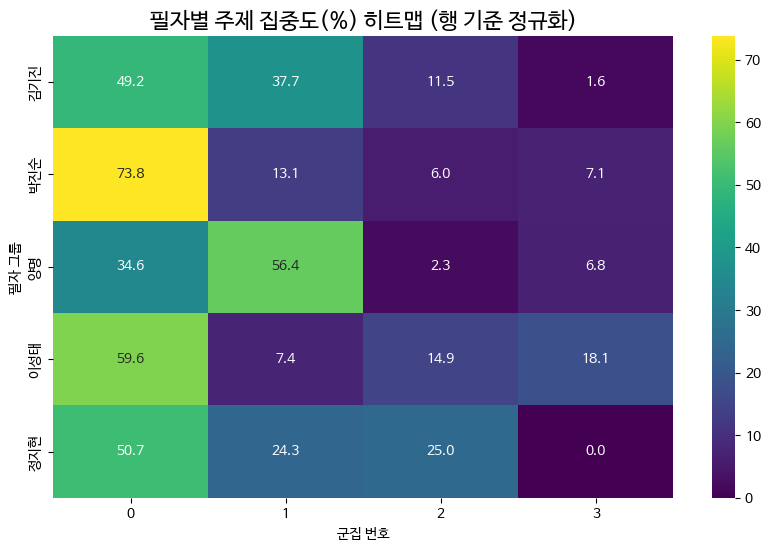

In [43]:
# =================================================================
# 5. 필자(행) 기준 정규화 및 히트맵 시각화
# =================================================================
print("\n--- 5. 필자(행) 기준으로 정규화된 매트릭스를 생성합니다. ---")

# 각 행(필자)의 합으로 각 셀을 나누어 비율을 계산하고, 100을 곱해 퍼센트로 만듭니다.
# axis=1은 행 방향으로 합계를 구하라는 의미, axis=0은 각 행에 대해 연산을 적용하라는 의미입니다.
writer_norm_matrix = writer_cluster_matrix_top5.div(writer_cluster_matrix_top5.sum(axis=1), axis=0) * 100

print("✅ [필자(행) 기준 정규화 매트릭스 (%)]")
# 소수점 둘째 자리까지만 표시
print(writer_norm_matrix.round(2))

print("\n--- 8. 정규화된 히트맵을 시각화합니다. ---")
plt.figure(figsize=(10, 6))
sns.heatmap(
    writer_norm_matrix,
    annot=True,
    fmt='.1f',      # 소수점 첫째 자리까지 표시
    cmap='viridis'  # 다른 색상 맵 사용
)
plt.title('필자별 주제 집중도(%) 히트맵 (행 기준 정규화)', fontsize=16)
plt.ylabel('필자 그룹')
plt.xlabel('군집 번호')
plt.show()

# The End of Note